In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: /Users/jagath-sajjan/BugginHell


In [2]:
from bughunt_env import BugHuntEnv

env = BugHuntEnv(seed=42)
obs, info = env.reset(seed=1)

print("Case:", info["case_name"])
print("Files:", obs.file_tree)
print("Failing test:", obs.failing_test)
print("\nSTDERR:\n", obs.stderr)

Case: off_by_one_cart_total
Files: ['README.md', 'cart.py', 'tests/test_cart.py', 'utils.py']
Failing test: test_calculate_total_counts_all_items

STDERR:
 FAILED tests/test_cart.py::test_calculate_total_counts_all_items\nE assert 30 == 60\nE where 30 = calculate_total([{'price': 10}, {'price': 20}, {'price': 30}])


In [3]:
actions = [
    (2, {"name": obs.failing_test}),
    (3, {"fn": "calculate_total"}),
    (0, {"path": "cart.py"}),
    (4, {"file": "cart.py", "line": 3}),
]

for action in actions:
    obs, reward, terminated, truncated, info = env.step(action)
    print("Action:", action)
    print("Reward:", reward)
    print("Output:", obs.last_tool_output)
    print("-" * 60)

    if terminated or truncated:
        break

Action: (2, {'name': 'test_calculate_total_counts_all_items'})
Reward: -0.1
Output: Symbol `test_calculate_total_counts_all_items` found in tests/test_cart.py
------------------------------------------------------------
Action: (3, {'fn': 'calculate_total'})
Reward: -0.1
Output: tests/test_cart.py calls calculate_total from cart.py
------------------------------------------------------------
Action: (0, {'path': 'cart.py'})
Reward: -0.1
Output: --- cart.py ---\ndef calculate_total(items):\n    total = 0\n    for i in range(len(items) - 1):\n        total += items[i]["price"]\n    return total\n
------------------------------------------------------------
Action: (4, {'file': 'cart.py', 'line': 3})
Reward: 1.1
Output: commit=cart.py:3, target=cart.py:3, correct_file=True, correct_line=True, steps=4/10, reward=1.10
------------------------------------------------------------


In [6]:
# Random Agentoooo

import random

def run_random_episode(env):
    obs, info = env.reset()
    total_reward = 0

    for _ in range(env.max_steps):
        action_id = random.randint(0, 4)

        if action_id == 0:
            action = (0, {"path": random.choice(obs.file_tree)})
        elif action_id == 1:
            action = (1, {"name": obs.failing_test})
        elif action_id == 2:
            action = (2, {"name": obs.failing_test})
        elif action_id == 3:
            action = (3, {"fn": "calculate_total"})
        else:
            action = (4, {"file": "random.py", "line": 999})

        obs, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward

        if terminated or truncated:
            break

    return total_reward

In [8]:
# Heuristic Agentttt
def run_heuristic_episode(env):
    obs, info = env.reset()
    total_reward = 0

    actions = [
        (2, {"name": obs.failing_test}),
        (3, {"fn": "calculate_total"}),
        (0, {"path": "cart.py"}),
        (4, {"file": "cart.py", "line": 3}),
    ]

    for action in actions:
        obs, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward

        if terminated or truncated:
            break

    return total_reward

In [9]:
# Runnnn Multpile Episodesssss
random_rewards = []
heuristic_rewards = []

for _ in range(50):
    env = BugHuntEnv()
    random_rewards.append(run_random_episode(env))

for _ in range(50):
    env = BugHuntEnv()
    heuristic_rewards.append(run_heuristic_episode(env))

print("Random avg:", sum(random_rewards)/len(random_rewards))
print("Heuristic avg:", sum(heuristic_rewards)/len(heuristic_rewards))

Random avg: -1.6059999999999999
Heuristic avg: -0.7


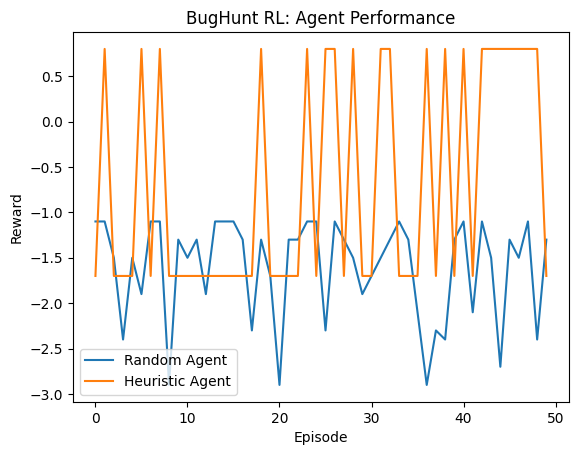

In [11]:
# MatplotLIBBBB
import matplotlib.pyplot as plt

plt.figure()
plt.plot(random_rewards, label="Random Agent")
plt.plot(heuristic_rewards, label="Heuristic Agent")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("BugHunt RL: Agent Performance")
plt.legend()
plt.show()